# Step1

In [48]:
# Import models and metrics
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [49]:
# Create data folder and copy dataset file

os.makedirs("data", exist_ok=True)

shutil.copy(
    "/kaggle/input/datasets/eylanalqazlan/uci-heart-disease-data/heart_disease_uci.csv",
    "data/heart_disease_uci.csv"
)
# Load dataset into pandas DataFrame
df = pd.read_csv("data/heart_disease_uci.csv")

# Show first rows and dataset structure
df.head()
# Check dataset shape
print(df.shape)
# Check missing values
print(df.isnull().sum())
# Show dataset info
print(df.info())

(920, 16)
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    

In [50]:
# Create target column (0 = no disease, 1 = disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
# Drop unnecessary columns
df = df.drop(columns=['id', 'num'], errors='ignore')

# Check class distribution
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

target
1    509
0    411
Name: count, dtype: int64
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


# The dataset is reasonably balanced because both classes appear in similar proportions.
# Therefore, both Accuracy and F1-score are useful evaluation metrics.

In [51]:
# Fill missing values using median for numbers and mode for categorical features
df.fillna(df.median(numeric_only=True), inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

/tmp/ipykernel_57/285197379.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [52]:
# Convert categorical variables into numeric using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [53]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
# Train Logistic Regression model
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)

In [56]:
# Train Random Forest model
rf_model = Pipeline([
    ('scaler', StandardScaler()),  
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

In [57]:
# Train K-Nearest Neighbors model
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_model.fit(X_train, y_train)
pred_knn = knn_model.predict(X_test)

In [58]:
# Evaluate all models using classification metrics
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))
print("------")

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1:", f1_score(y_test, pred_rf))
print("------")

print("KNN")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Precision:", precision_score(y_test, pred_knn))
print("Recall:", recall_score(y_test, pred_knn))
print("F1:", f1_score(y_test, pred_knn))
print("------")

Logistic Regression
Accuracy: 0.8369565217391305
Precision: 0.8272727272727273
Recall: 0.8921568627450981
F1: 0.8584905660377359
------
Random Forest
Accuracy: 0.8369565217391305
Precision: 0.8272727272727273
Recall: 0.8921568627450981
F1: 0.8584905660377359
------
KNN
Accuracy: 0.8641304347826086
Precision: 0.8468468468468469
Recall: 0.9215686274509803
F1: 0.8826291079812206
------


In [59]:
# Store all model results in a table for comparison
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, pred_lr),
        "Precision": precision_score(y_test, pred_lr),
        "Recall": recall_score(y_test, pred_lr),
        "F1": f1_score(y_test, pred_lr)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, pred_rf),
        "Precision": precision_score(y_test, pred_rf),
        "Recall": recall_score(y_test, pred_rf),
        "F1": f1_score(y_test, pred_rf)
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, pred_knn),
        "Precision": precision_score(y_test, pred_knn),
        "Recall": recall_score(y_test, pred_knn),
        "F1": f1_score(y_test, pred_knn)
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491
1,Random Forest,0.836957,0.827273,0.892157,0.858491
2,KNN,0.864130,0.846847,0.921569,0.882629


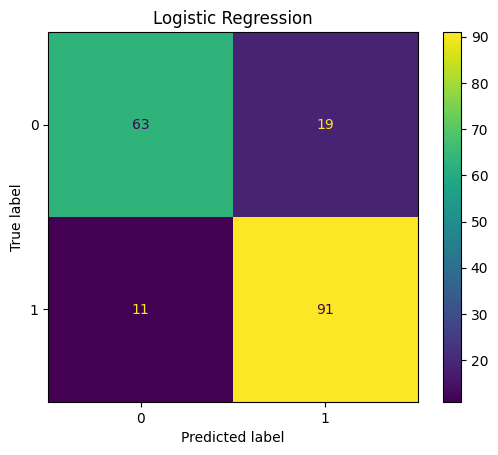

In [60]:
# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")
plt.show()

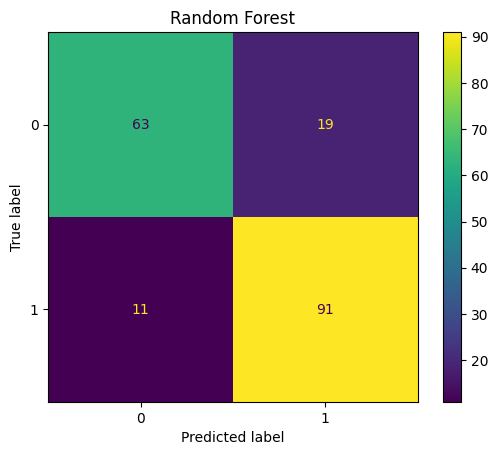

In [61]:
# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")
plt.show()

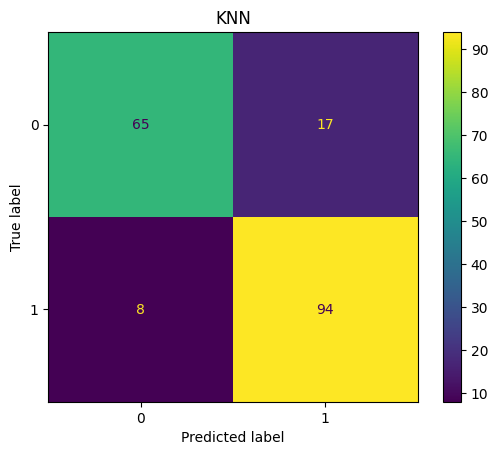

In [62]:
# Confusion Matrix - KNN Model
cm = confusion_matrix(y_test, pred_knn)
ConfusionMatrixDisplay(cm).plot()
plt.title("KNN")
plt.show()

In [63]:
# Final conclusion
print("Best model is KNN because it achieved the highest F1-score and accuracy.")

Best model is KNN because it achieved the highest F1-score and accuracy.


# Step 2 — Neural Network

In [65]:
# Compile neural network
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [66]:
# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Show model structure
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [67]:
# Scale data for neural network
scaler_nn = StandardScaler()

X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn = scaler_nn.transform(X_test)

In [68]:
# Train the model
history = model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5781 - loss: 0.6787 - val_accuracy: 0.8311 - val_loss: 0.4705
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7831 - loss: 0.4926 - val_accuracy: 0.8176 - val_loss: 0.3998
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8218 - loss: 0.4442 - val_accuracy: 0.8311 - val_loss: 0.3849
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8579 - loss: 0.3724 - val_accuracy: 0.8243 - val_loss: 0.3823
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8365 - loss: 0.3974 - val_accuracy: 0.8243 - val_loss: 0.3814
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8256 - loss: 0.4053 - val_accuracy: 0.8311 - val_loss: 0.3821
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8149 - loss: 0.3718 - val_accuracy: 0.8311 - val_loss: 0.3840
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8701 - loss: 0.3482 - val_accuracy: 0.8378 - val_loss

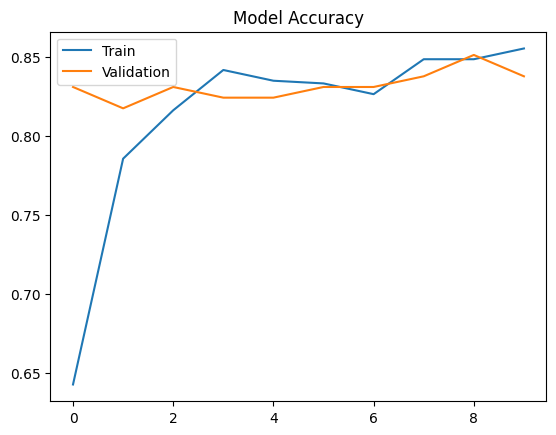

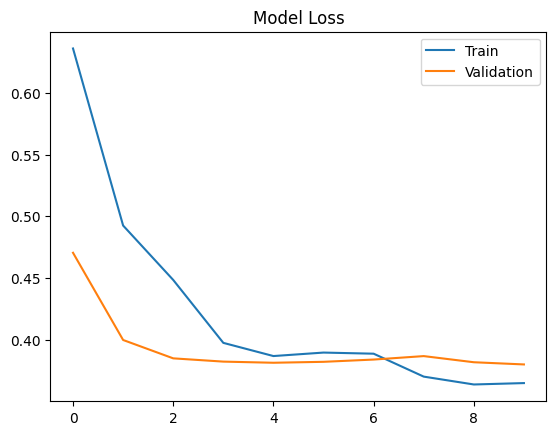

In [69]:
# Plot accuracy and loss curves

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [70]:
# Make predictions on test data
y_pred = model.predict(X_test_nn)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [71]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.842391304347826
Precision: 0.8230088495575221
Recall: 0.9117647058823529
F1: 0.8651162790697674


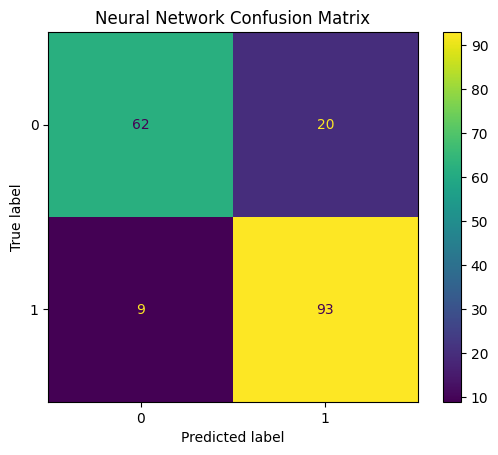

In [72]:
# Confusion Matrix - Neural Network

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [73]:
# Add neural network results to table
results.append({
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491
1,Random Forest,0.836957,0.827273,0.892157,0.858491
2,KNN,0.864130,0.846847,0.921569,0.882629
3,Neural Network,0.842391,0.823009,0.911765,0.865116


In [74]:
# Sort models by best F1-score
results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,KNN,0.864130,0.846847,0.921569,0.882629
3,Neural Network,0.842391,0.823009,0.911765,0.865116
1,Random Forest,0.836957,0.827273,0.892157,0.858491
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491


## Best Model

After comparing all models using Accuracy, Precision, Recall, and F1-score, the KNN model performed the best overall. It achieved the highest F1-score, making it the most reliable model for this classification task.

In [75]:
model.save("heart_model.h5") 

In [76]:
print(os.listdir("/kaggle/working"))

['heart_model.h5', '.virtual_documents', 'data']


In [77]:
from IPython.display import FileLink

FileLink("heart_model.h5")

/kaggle/working/heart_model.h5